# Детекция на финансови измами (PaySim)

**Тема (дипломна работа):** Методи за детекция на финансови измами чрез машинно обучение при небалансирани данни.

Pipeline: EDA → preprocessing → корелации → PCA → крос-валидация с метрики, разширен със **стратегии за небалансирани класове** (class weights, SMOTE, undersampling) и **ROC AUC / PR AUC / F1** за по-адекватна оценка при рядък положителен клас.

**Dataset:** PaySim (синтетични мобилни плащания). CSV се очаква в `data/paysim.csv` (виж `scripts/download_paysim.py`).


## 1. Imports и зареждане на данните


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")


In [2]:
# Paths and sampling
DATA_PATH = Path("data/paysim.csv")
SAMPLE_SIZE = 300_000  # stratified subsample for faster training (esp. SVM)
RANDOM_STATE = 42

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run: python scripts/download_paysim.py "
        "or download PaySim manually into data/paysim.csv"
    )

# Премахва nameOrig, за да намали паметта; запазва nameDest за флаг за търговец
usecols = [
    "step",
    "type",
    "amount",
    "nameDest",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud",
]

# Типове на данните
dtypes = {
    "step": "int32",
    "amount": "float32",
    "oldbalanceOrg": "float32",
    "newbalanceOrig": "float32",
    "oldbalanceDest": "float32",
    "newbalanceDest": "float32",
    "isFraud": "int8",
    "isFlaggedFraud": "int8",
}

df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, low_memory=False)
print("Loaded rows:", len(df))
print("Fraud rate:", df["isFraud"].mean())

if len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        stratify=df["isFraud"],
        random_state=RANDOM_STATE,
        shuffle=True,
    )
    
    df = df.reset_index(drop=True)

print("After stratified subsample:", len(df), "fraud rate:", df["isFraud"].mean())


Loaded rows: 6362620
Fraud rate: 0.001290820448180152
After stratified subsample: 300000 fraud rate: 0.00129


## 2. Изследване на данните (EDA)


In [3]:
print("==== Head ====")
display(df.head())

print("\n==== Info ====")
df.info()

print("\n==== Describe ====")
display(df.describe())

print("\n==== Null counts ====")
display(df.isnull().sum())


==== Head ====


,step,type,amount,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,47,PAYMENT,5661.379883,101806.0,96144.617188,M1724774327,0.0,0.0,0,0
1,550,PAYMENT,9033.589844,0.0,0.000000,M1303408874,0.0,0.0,0,0
2,399,PAYMENT,40710.800781,43871.0,3160.199951,M1262896233,0.0,0.0,0,0
3,255,PAYMENT,9359.980469,0.0,0.000000,M2144867138,0.0,0.0,0,0
4,235,PAYMENT,3850.370117,0.0,0.000000,M9504230,0.0,0.0,0,0



==== Info ====
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            300000 non-null  int32  
 1   type            300000 non-null  str    
 2   amount          300000 non-null  float32
 3   oldbalanceOrg   300000 non-null  float32
 4   newbalanceOrig  300000 non-null  float32
 5   nameDest        300000 non-null  str    
 6   oldbalanceDest  300000 non-null  float32
 7   newbalanceDest  300000 non-null  float32
 8   isFraud         300000 non-null  int8   
 9   isFlaggedFraud  300000 non-null  int8   
dtypes: float32(5), int32(1), int8(2), str(2)
memory usage: 12.0 MB

==== Describe ====


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,300000.000000,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,3.000000e+05,300000.000000,300000.000000
mean,243.540203,1.811994e+05,8.318961e+05,8.529579e+05,1.109395e+06,1.234785e+06,0.001290,0.000010
std,142.386675,6.202330e+05,2.886043e+06,2.920700e+06,3.542792e+06,3.819226e+06,0.035893,0.003162
min,1.000000,4.100000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.339359e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,240.000000,7.486945e+04,1.371700e+04,0.000000e+00,1.325924e+05,2.144388e+05,0.000000,0.000000
75%,335.000000,2.089515e+05,1.067848e+05,1.425161e+05,9.483363e+05,1.114427e+06,0.000000,0.000000
max,743.000000,6.988673e+07,5.731626e+07,4.731626e+07,3.551855e+08,3.553805e+08,1.000000,1.000000



==== Null counts ====


step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

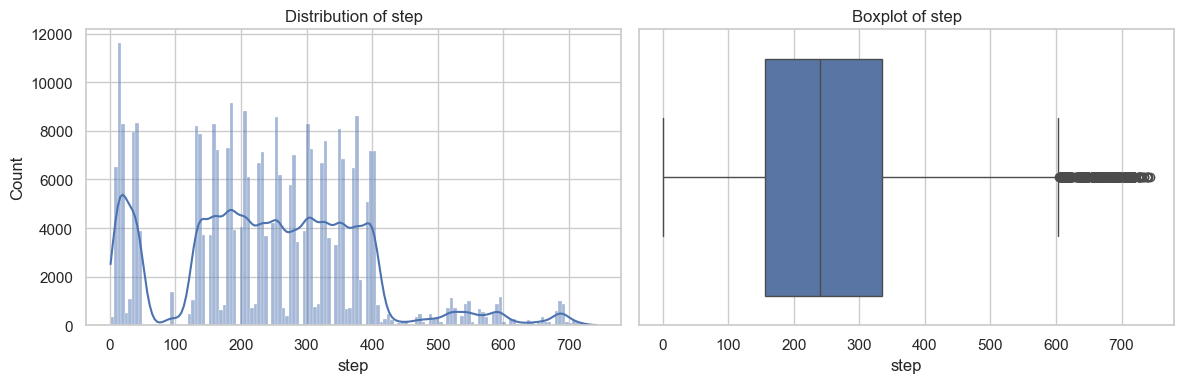

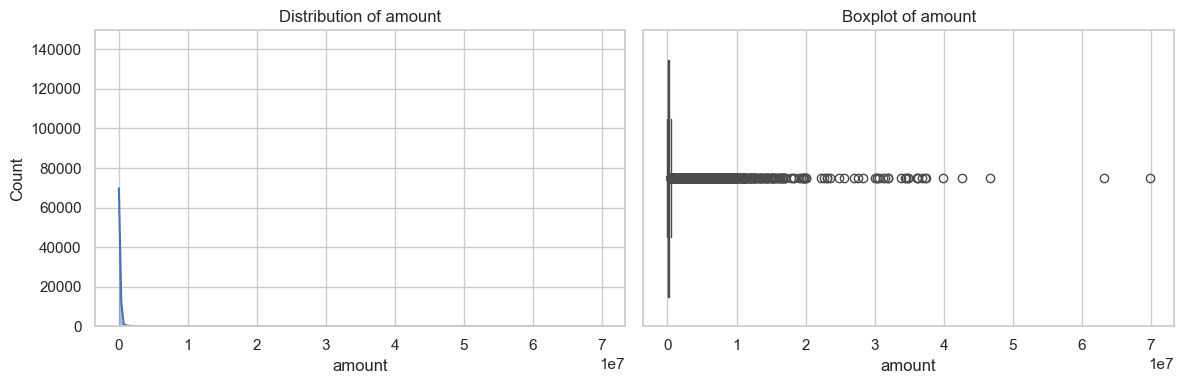

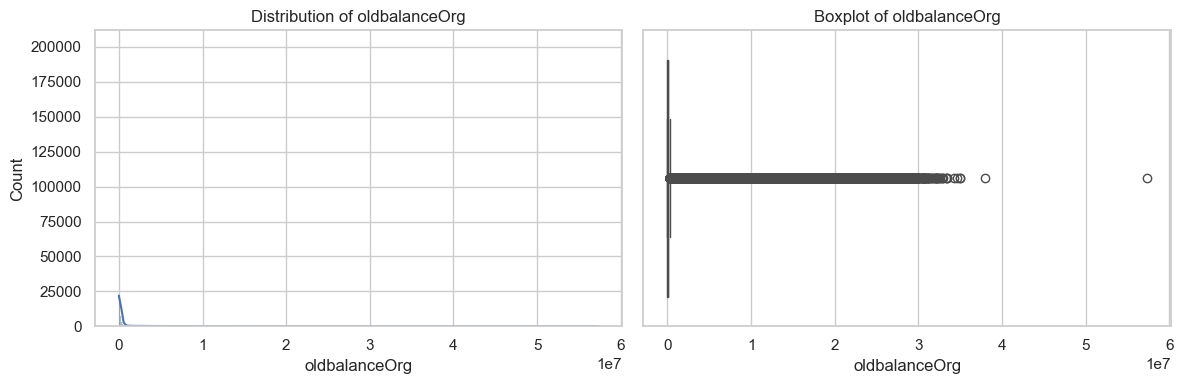

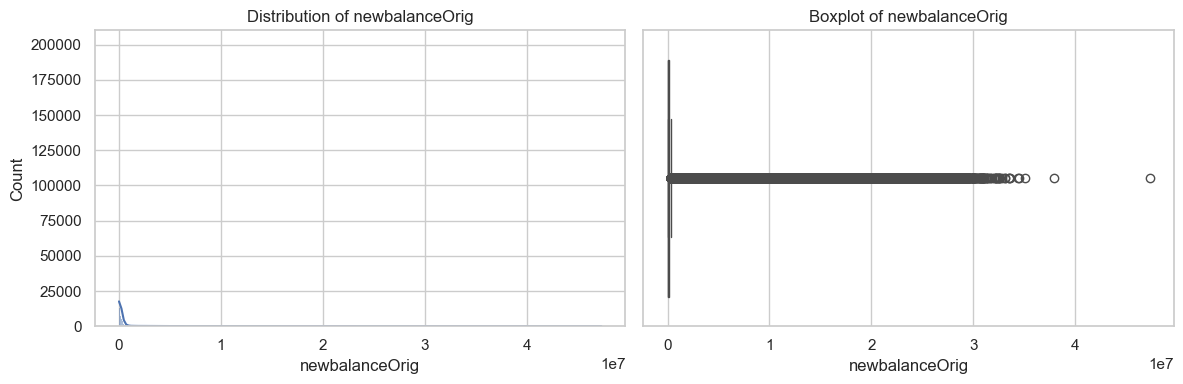

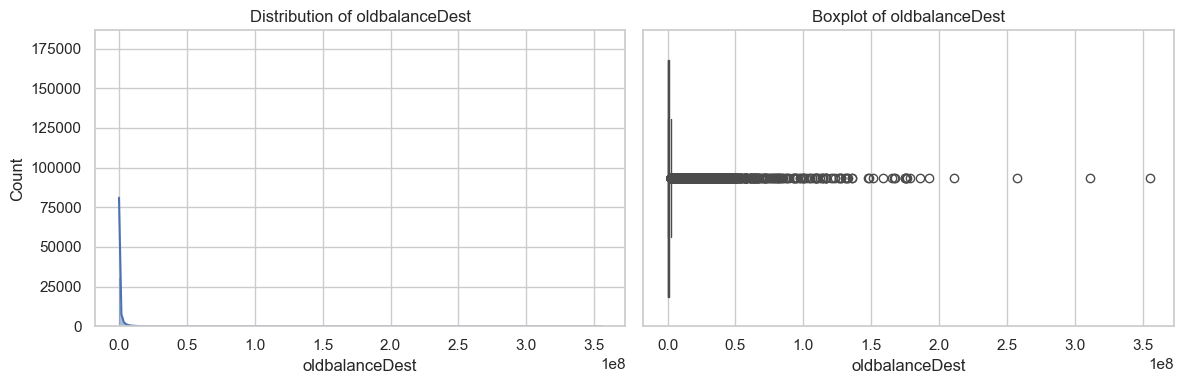

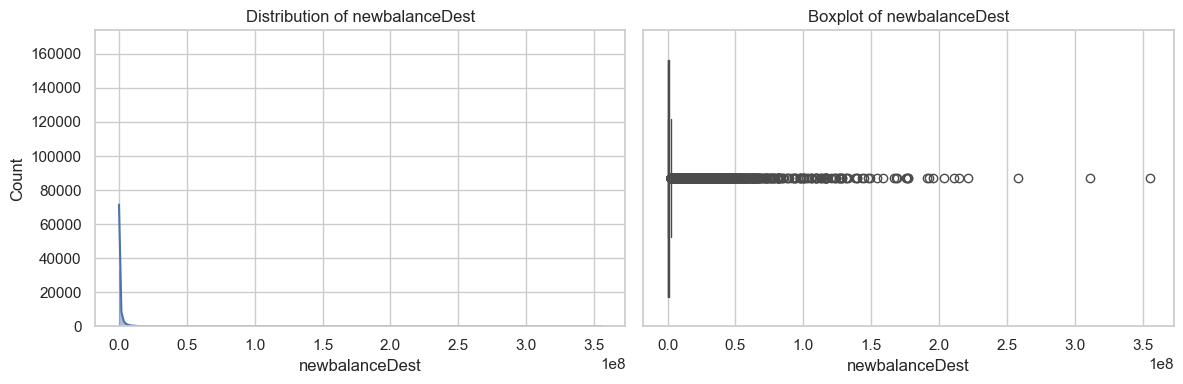

In [4]:
# Charts for numerical columns
numerical_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


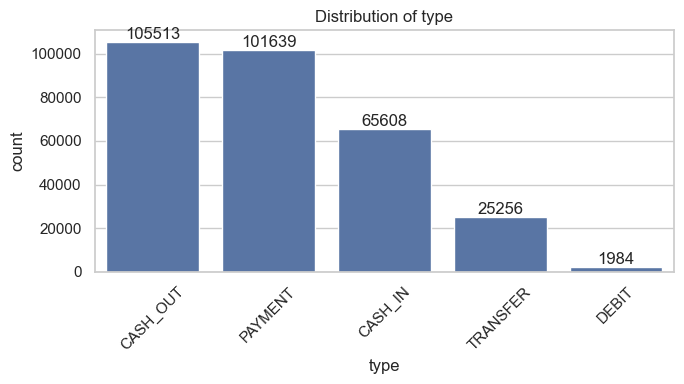

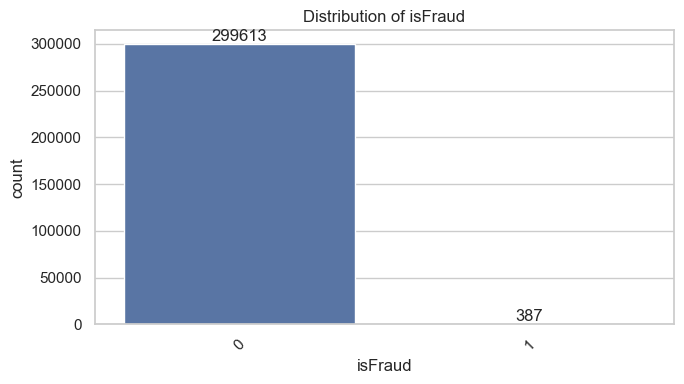

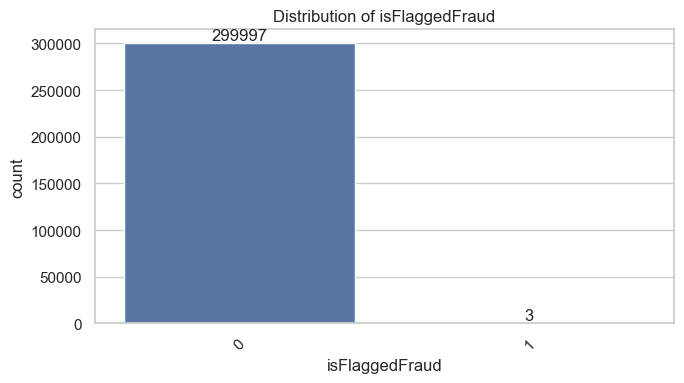

In [5]:
# Categorical / binary columns
cat_cols = ["type", "isFraud", "isFlaggedFraud"]

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    order = df[col].value_counts().index
    ax = sns.countplot(data=df, x=col, order=order)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2.0, h), ha="center", va="bottom")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


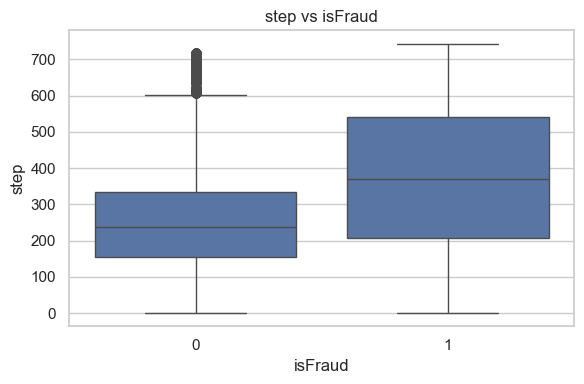

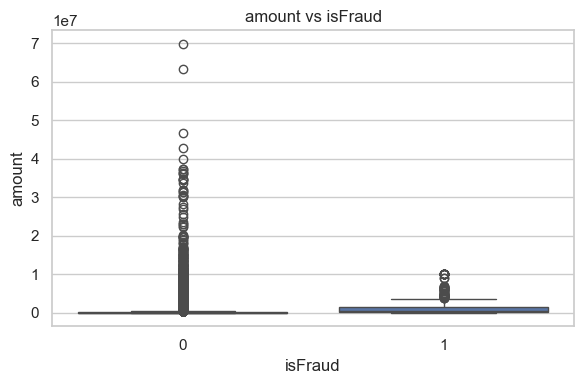

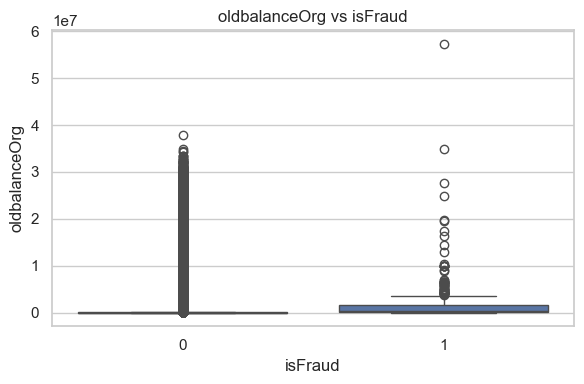

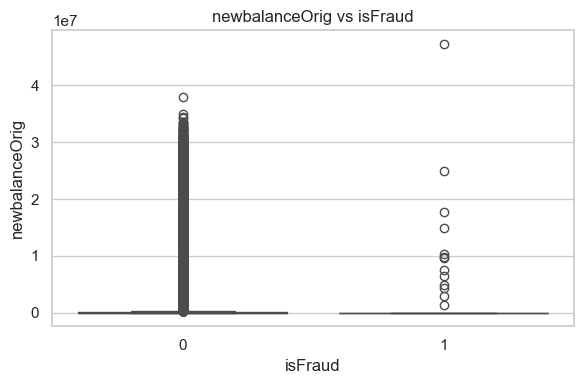

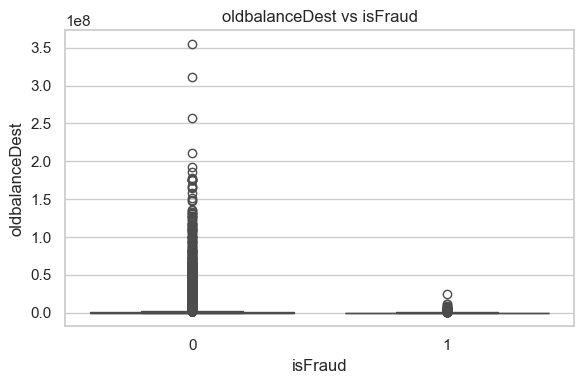

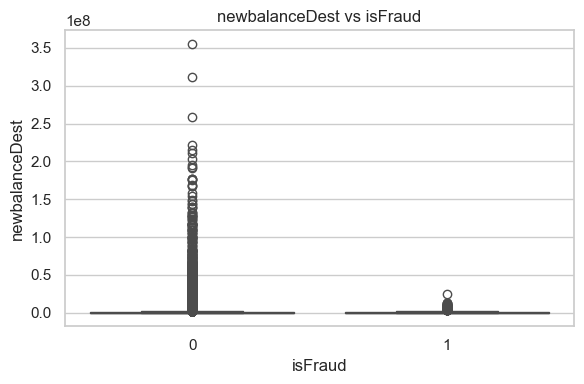

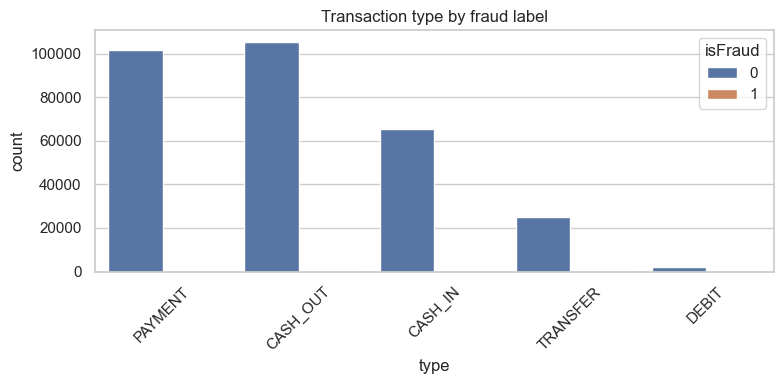

In [6]:
# Bivariate analysis
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="isFraud", y=col)
    plt.title(f"{col} vs isFraud")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="type", hue="isFraud")
plt.title("Transaction type by fraud label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Предварителна обработка


In [7]:
df_original = df.copy()


In [8]:
# Feature engineering specific to PaySim
# Balance conservation errors capture anomalous flows (common fraud signal)
df["errorBalanceOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]
# Merchant accounts in PaySim have names starting with 'M'
df["merchantDest"] = df["nameDest"].astype(str).str.startswith("M").astype(np.int8)
df = df.drop(columns=["nameDest"])

# One-hot encode transaction type
df_encoded = pd.get_dummies(df, columns=["type"], drop_first=False)

print("Encoded shape:", df_encoded.shape)
display(df_encoded.head())


Encoded shape: (300000, 16)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,merchantDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,47,5661.379883,101806.0,96144.617188,0.0,0.0,0,0,0.000000,5661.379883,1,False,False,False,True,False
1,550,9033.589844,0.0,0.000000,0.0,0.0,0,0,-9033.589844,9033.589844,1,False,False,False,True,False
2,399,40710.800781,43871.0,3160.199951,0.0,0.0,0,0,-0.000732,40710.800781,1,False,False,False,True,False
3,255,9359.980469,0.0,0.000000,0.0,0.0,0,0,-9359.980469,9359.980469,1,False,False,False,True,False
4,235,3850.370117,0.0,0.000000,0.0,0.0,0,0,-3850.370117,3850.370117,1,False,False,False,True,False


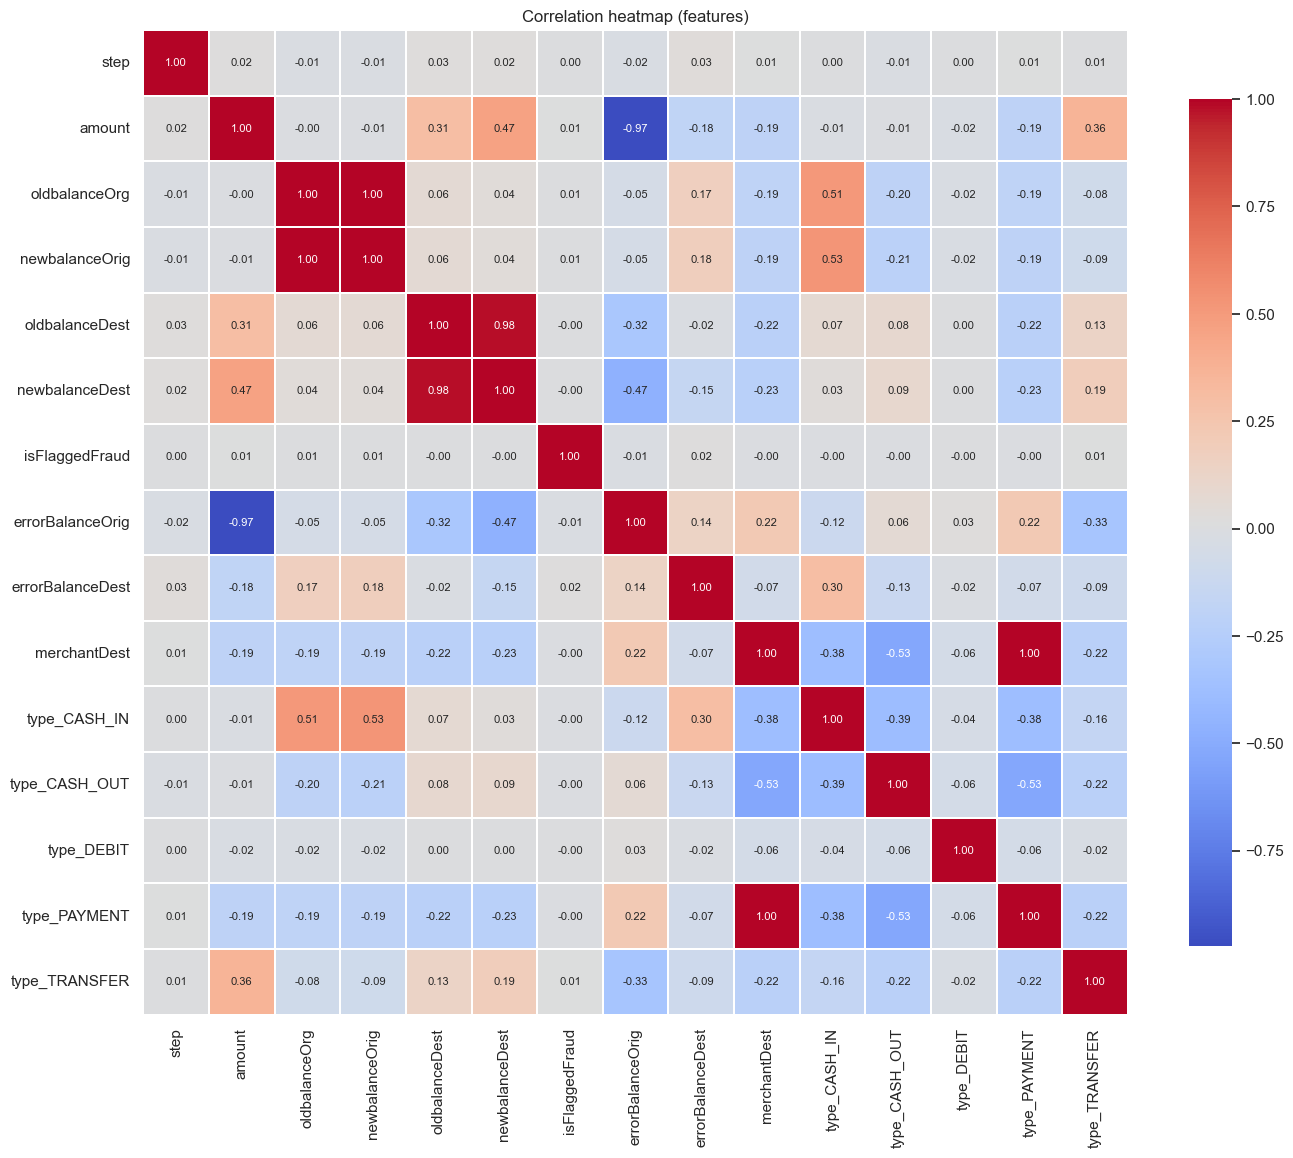

In [9]:
# Correlation heatmap (features only; target kept separate for modeling)
TARGET_COL = "isFraud"
feature_cols = [c for c in df_encoded.columns if c != TARGET_COL]
df_features = df_encoded[feature_cols]

corr_matrix = df_features.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation heatmap (features)")
plt.tight_layout()
plt.show()


In [10]:
def reduce_dimensionality_corr(df_corr: pd.DataFrame, corr_threshold: float = 0.8):
    # Drop one feature from pairs with |corr| > corr_threshold (upper triangle)
    corr_matrix = df_corr.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    redundant = list(set(redundant))
    df_selected = df_corr.drop(columns=redundant, errors="ignore")
    return df_selected, redundant


df_selected, dropped_redundant = reduce_dimensionality_corr(df_features)

n_before = df_features.shape[1]
n_after = df_selected.shape[1]
n_dropped = len(dropped_redundant)
print(
    f"Преди: {n_before} колони → След: {n_after} колони "
    f"(премахнати {n_dropped} при corr > 0.8)"
)

feature_summary = pd.DataFrame(
    {
        "column": df_features.columns,
        "status": np.where(
            df_features.columns.isin(dropped_redundant), "removed", "kept"
        ),
    }
)
print("\nОбобщение (всички feature колони):")
display(feature_summary.sort_values(["status", "column"], ascending=[True, True]))

dropped_df = pd.DataFrame({"column": sorted(dropped_redundant)})
print(f"\nПремахнати колони ({n_dropped}):")
display(dropped_df)

remaining_df = pd.DataFrame({"column": df_selected.columns.tolist()})
print(f"\nЗапазени колони ({n_after}):")
display(remaining_df)

print("\nPreview of reduced feature matrix:")
display(df_selected.head())

Преди: 15 колони → След: 11 колони (премахнати 4 при corr > 0.8)

Обобщение (всички feature колони):


,column,status
1,amount,kept
8,errorBalanceDest,kept
6,isFlaggedFraud,kept
9,merchantDest,kept
4,oldbalanceDest,kept
2,oldbalanceOrg,kept
0,step,kept
10,type_CASH_IN,kept
11,type_CASH_OUT,kept
12,type_DEBIT,kept



Премахнати колони (4):


,column
0,errorBalanceOrig
1,newbalanceDest
2,newbalanceOrig
3,type_PAYMENT



Запазени колони (11):


,column
0,step
1,amount
2,oldbalanceOrg
3,oldbalanceDest
4,isFlaggedFraud
5,errorBalanceDest
6,merchantDest
7,type_CASH_IN
8,type_CASH_OUT
9,type_DEBIT



Preview of reduced feature matrix:


,step,amount,oldbalanceOrg,oldbalanceDest,isFlaggedFraud,errorBalanceDest,merchantDest,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_TRANSFER
0,47,5661.379883,101806.0,0.0,0,5661.379883,1,False,False,False,False
1,550,9033.589844,0.0,0.0,0,9033.589844,1,False,False,False,False
2,399,40710.800781,43871.0,0.0,0,40710.800781,1,False,False,False,False
3,255,9359.980469,0.0,0.0,0,9359.980469,1,False,False,False,False
4,235,3850.370117,0.0,0.0,0,3850.370117,1,False,False,False,False


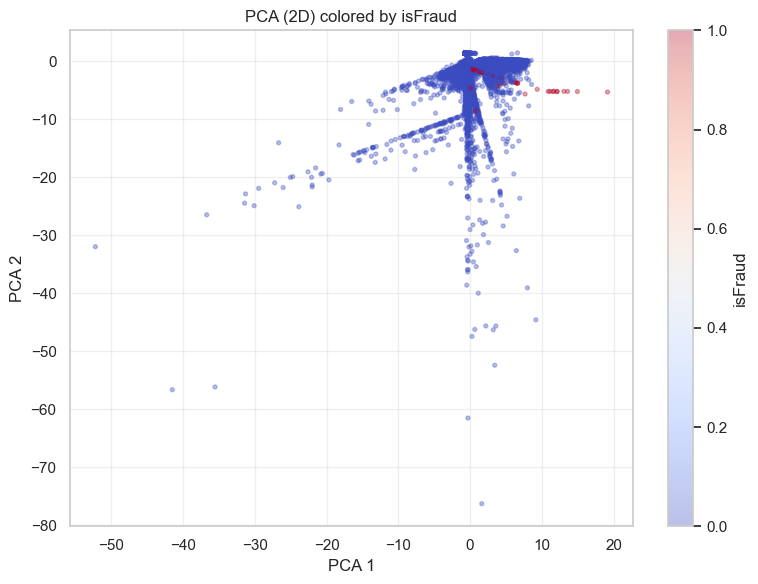

In [11]:
# PCA 2D projection (fraud vs non-fraud)
X_pca_all = df_selected
y_vis = df_encoded[TARGET_COL].values

scaler_vis = StandardScaler()
X_scaled = scaler_vis.fit_transform(X_pca_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_vis, cmap="coolwarm", alpha=0.35, s=8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA (2D) colored by isFraud")
plt.colorbar(label="isFraud")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Стратегии за работа с небалансирани данни


Класът **измама** е силно малцинствен (порядък ~0.1–0.2% в PaySim). При такъв дисбаланс **accuracy** често е подвеждаща метрика.

В този раздел сравняваме четири подхода към обучителните данни **само вътре във всеки train fold** на крос-валидацията:

- **none** — без корекция (baseline).
- **class_weight** — тежести `balanced` (и еквивалент за boosting чрез `scale_pos_weight` където е приложимо).
- **smote** — синтетично овърсемплиране на малцинствения клас върху train.
- **undersample** — `RandomUnderSampler` върху train (по подразбиране към балансирани класове).

**Важно (data leakage):** SMOTE/undersampling **не** се прилага върху целия dataset преди split — това изкуствено „изтича“ информация от validation/test към train. Правилният ред е: `StratifiedKFold` → resampling **само** на `X_train, y_train` → scaling (ако е нужно) → `fit`.


isFraud
0    299613
1       387
Name: count, dtype: int64


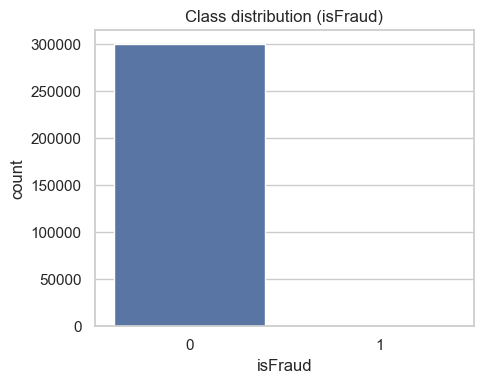

In [12]:
# Visualize imbalance
vc = df_encoded[TARGET_COL].value_counts().sort_index()
print(vc)
plt.figure(figsize=(5, 4))
sns.barplot(x=vc.index.astype(str), y=vc.values)
plt.title("Class distribution (isFraud)")
plt.xlabel("isFraud")
plt.ylabel("count")
plt.tight_layout()
plt.show()

STRATEGIES = ["none", "class_weight", "smote", "undersample"]


## 5. Обучение на моделите и доклади (LR, RF, SVM)


In [13]:
# Prepare X, y
X = df_selected.copy()
y = df_encoded[TARGET_COL].astype(int)

assert len(X) == len(y)
print(X.shape, y.value_counts())

summary_rows = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def _apply_sampling(strategy: str, X_tr: pd.DataFrame, y_tr: pd.Series):
    if strategy == "smote": #създаваме синтетични примери с измами
        sm = SMOTE(random_state=RANDOM_STATE)
        Xr, yr = sm.fit_resample(X_tr, y_tr)
        return pd.DataFrame(Xr, columns=X_tr.columns), pd.Series(yr, name=TARGET_COL)
    if strategy == "undersample": #изтриваме примери от преобладаващия клас (нормални транзакции)
        rus = RandomUnderSampler(random_state=RANDOM_STATE)
        Xr, yr = rus.fit_resample(X_tr, y_tr)
        return pd.DataFrame(Xr, columns=X_tr.columns), pd.Series(yr, name=TARGET_COL)
    return X_tr, y_tr


def _safe_roc_pr(y_true, y_score):
    try:
        roc = roc_auc_score(y_true, y_score) #колко добре модела разделя двата класа
    except Exception:
        roc = np.nan
    try:
        pr = average_precision_score(y_true, y_score) #средна точност на позитивните примери
    except Exception:
        pr = np.nan
    return roc, pr


def train_models_and_print_results(X_df, y_ser, models: dict, strategy: str, model_family: str):
    # Stratified CV with optional resampling on train folds only.
    for model_name, model_template in models.items():
        print(f"\n{'='*20} {model_family} | {model_name} | strategy={strategy} {'='*20}")

        fold_rows = []

        for fold, (train_idx, test_idx) in enumerate(skf.split(X_df, y_ser), start=1):
            X_train = X_df.iloc[train_idx]
            X_test = X_df.iloc[test_idx]
            y_train = y_ser.iloc[train_idx]
            y_test = y_ser.iloc[test_idx]

            X_train_s, y_train_s = _apply_sampling(strategy, X_train, y_train)

            model = clone(model_template)

            needs_scale = model_name in ("Logistic Regression", "SVM")
            if needs_scale:
                scaler = StandardScaler()
                X_tr = scaler.fit_transform(X_train_s)
                X_te = scaler.transform(X_test)
            else:
                X_tr = X_train_s.to_numpy()
                X_te = X_test.to_numpy()

            model.fit(X_tr, y_train_s)

            y_pred = model.predict(X_te)

            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_te)[:, 1]
            elif hasattr(model, "decision_function"):
                y_score = model.decision_function(X_te)
            else:
                y_score = y_pred.astype(float)

            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            if cm.size == 4:
                tn, fp, fn, tp = cm.ravel()
            else:
                tn = fp = fn = tp = np.nan

            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            spec = tn / (tn + fp) if (tn + fp) else np.nan
            roc, pr_auc = _safe_roc_pr(y_test, y_score)

            fold_rows.append(
                {
                    "Fold": fold,
                    "TP": tp,
                    "TN": tn,
                    "FP": fp,
                    "FN": fn,
                    "Accuracy": acc,
                    "Precision": prec,
                    "Recall": rec,
                    "F1": f1,
                    "Specificity": spec,
                    "ROC_AUC": roc,
                    "PR_AUC": pr_auc,
                }
            )

        df_res = pd.DataFrame(fold_rows)
        numeric_cols = [c for c in df_res.columns if c != "Fold"]
        mean_metrics = df_res[numeric_cols].mean(numeric_only=True)
        mean_row = mean_metrics.to_frame().T
        mean_row.insert(0, "Fold", "Mean")

        display(pd.concat([df_res, mean_row], ignore_index=True).round(6))
        summary_rows.append(
            {
                "Family": model_family,
                "Model": model_name,
                "Strategy": strategy,
                "Mean_Recall": mean_metrics["Recall"],
                "Mean_Precision": mean_metrics["Precision"],
                "Mean_F1": mean_metrics["F1"],
                "Mean_PR_AUC": mean_metrics["PR_AUC"],
                "Mean_ROC_AUC": mean_metrics["ROC_AUC"],
            }
        )

        # Feature importances / coefficients (tree models + LR)
        n_features = len(X_df.columns)
        if model_name in ("Random Forest", "LightGBM", "XGBoost"):
            importances = model.feature_importances_
            feat_df = pd.DataFrame({"Feature": X_df.columns, "Importance": importances}).sort_values(
                "Importance", ascending=False
            )
            plt.figure(figsize=(10, max(4, 0.35 * n_features)))
            sns.barplot(data=feat_df.head(n_features), x="Importance", y="Feature", palette="viridis")
            plt.title(f"Feature importances — {model_name} ({strategy})")
            plt.tight_layout()
            plt.show()
        elif model_name == "Logistic Regression" and hasattr(model, "coef_"):
            coefs = np.abs(model.coef_[0])
            feat_df = pd.DataFrame({"Feature": X_df.columns, "AbsCoef": coefs}).sort_values("AbsCoef", ascending=False)
            plt.figure(figsize=(10, max(4, 0.35 * n_features)))
            sns.barplot(data=feat_df.head(n_features), x="AbsCoef", y="Feature", palette="magma")
            plt.title(f"|coef| by feature — {model_name} ({strategy})")
            plt.tight_layout()
            plt.show()

(300000, 11) isFraud
0    299613
1       387
Name: count, dtype: int64



==================== sklearn | Logistic Regression | strategy=none ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,21.0,59923.0,0.0,56.0,0.999067,1.000000,0.272727,0.428571,1.000000,0.934611,0.445525
1,2,18.0,59922.0,1.0,59.0,0.999000,0.947368,0.233766,0.375000,0.999983,0.928604,0.336134
2,3,17.0,59919.0,4.0,60.0,0.998933,0.809524,0.220779,0.346939,0.999933,0.952950,0.360563
3,4,26.0,59918.0,4.0,52.0,0.999067,0.866667,0.333333,0.481481,0.999933,0.950815,0.469073
4,5,14.0,59920.0,2.0,64.0,0.998900,0.875000,0.179487,0.297872,0.999967,0.931911,0.369662
5,Mean,19.2,59920.4,2.2,58.2,0.998993,0.899712,0.248019,0.385973,0.999963,0.939778,0.396191


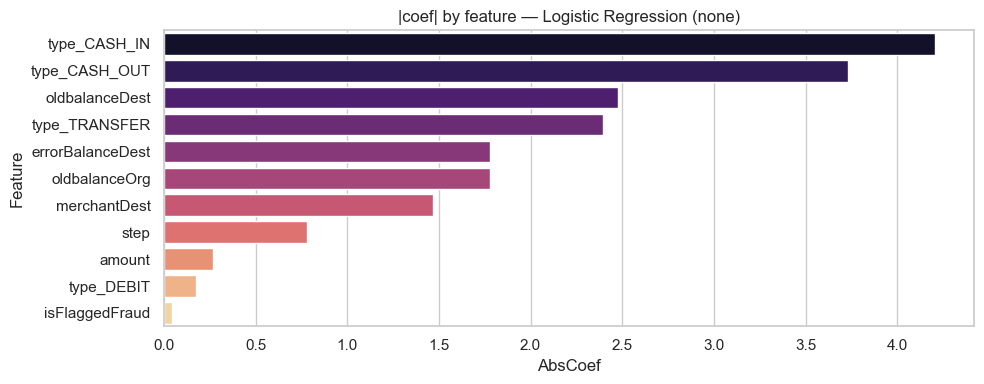


==================== sklearn | Random Forest | strategy=none ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,50.0,59922.0,1.0,27.0,0.999533,0.980392,0.649351,0.781250,0.999983,0.958582,0.763015
1,2,52.0,59922.0,1.0,25.0,0.999567,0.981132,0.675325,0.800000,0.999983,0.959144,0.831899
2,3,50.0,59921.0,2.0,27.0,0.999517,0.961538,0.649351,0.775194,0.999967,0.939196,0.729894
3,4,63.0,59919.0,3.0,15.0,0.999700,0.954545,0.807692,0.875000,0.999950,0.973579,0.900351
4,5,56.0,59921.0,1.0,22.0,0.999617,0.982456,0.717949,0.829630,0.999983,0.966173,0.815055
5,Mean,54.2,59921.0,1.6,23.2,0.999587,0.972013,0.699933,0.812215,0.999973,0.959335,0.808043


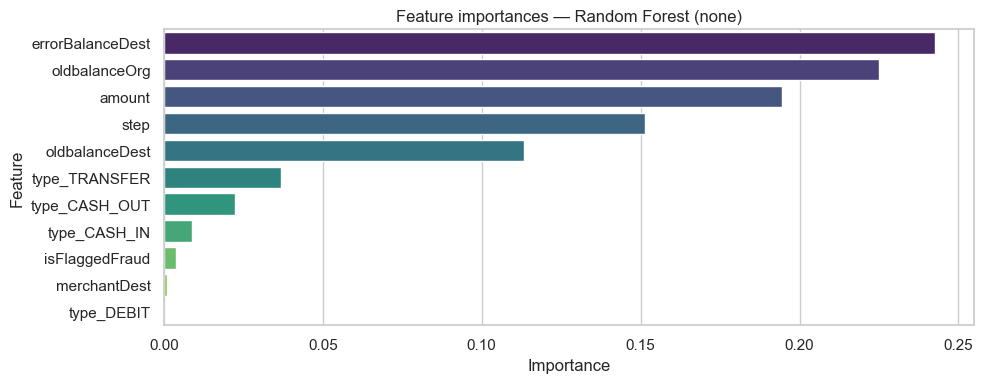


==================== sklearn | SVM | strategy=none ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,16.0,59923.0,0.0,61.0,0.998983,1.000000,0.207792,0.344086,1.000000,0.950683,0.482676
1,2,15.0,59920.0,3.0,62.0,0.998917,0.833333,0.194805,0.315789,0.999950,0.954160,0.404924
2,3,15.0,59921.0,2.0,62.0,0.998933,0.882353,0.194805,0.319149,0.999967,0.971420,0.386425
3,4,18.0,59918.0,4.0,60.0,0.998933,0.818182,0.230769,0.360000,0.999933,0.977021,0.483239
4,5,11.0,59922.0,0.0,67.0,0.998883,1.000000,0.141026,0.247191,1.000000,0.952100,0.440770
5,Mean,15.0,59920.8,1.8,62.4,0.998930,0.906774,0.193839,0.317243,0.999970,0.961077,0.439607



==================== sklearn | Logistic Regression | strategy=class_weight ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,68.0,55942.0,3981.0,9.0,0.933500,0.016794,0.883117,0.032962,0.933565,0.976134,0.288959
1,2,71.0,55772.0,4151.0,6.0,0.930717,0.016817,0.922078,0.033031,0.930728,0.979515,0.195356
2,3,75.0,55877.0,4046.0,2.0,0.932533,0.018199,0.974026,0.035731,0.932480,0.982342,0.180695
3,4,77.0,55583.0,4339.0,1.0,0.927667,0.017437,0.987179,0.034268,0.927589,0.988283,0.200966
4,5,69.0,56036.0,3886.0,9.0,0.935083,0.017446,0.884615,0.034218,0.935149,0.974408,0.270365
5,Mean,72.0,55842.0,4080.6,5.4,0.931900,0.017339,0.930203,0.034042,0.931902,0.980136,0.227268


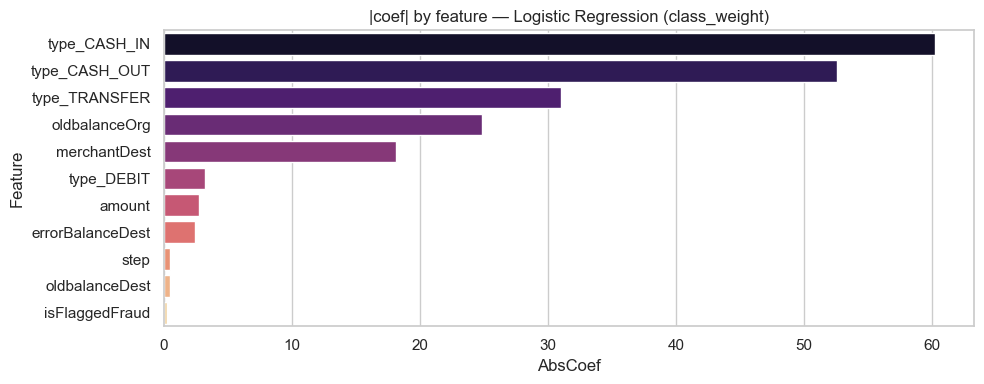


==================== sklearn | Random Forest | strategy=class_weight ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,49.0,59922.0,1.0,28.0,0.999517,0.980000,0.636364,0.771654,0.999983,0.966092,0.776048
1,2,52.0,59923.0,0.0,25.0,0.999583,1.000000,0.675325,0.806202,1.000000,0.953151,0.831820
2,3,50.0,59921.0,2.0,27.0,0.999517,0.961538,0.649351,0.775194,0.999967,0.972462,0.768601
3,4,62.0,59921.0,1.0,16.0,0.999717,0.984127,0.794872,0.879433,0.999983,0.973512,0.886560
4,5,55.0,59919.0,3.0,23.0,0.999567,0.948276,0.705128,0.808824,0.999950,0.960403,0.817892
5,Mean,53.6,59921.2,1.4,23.8,0.999580,0.974788,0.692208,0.808261,0.999977,0.965124,0.816184


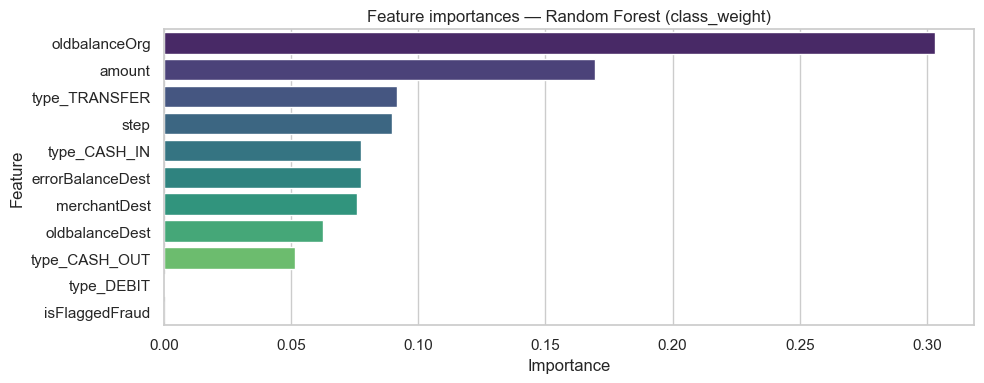


==================== sklearn | SVM | strategy=class_weight ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,68.0,55978.0,3945.0,9.0,0.934100,0.016945,0.883117,0.033252,0.934166,0.974288,0.306345
1,2,70.0,55823.0,4100.0,7.0,0.931550,0.016787,0.909091,0.032964,0.931579,0.977626,0.194935
2,3,74.0,55968.0,3955.0,3.0,0.934033,0.018367,0.961039,0.036045,0.933999,0.981556,0.223904
3,4,77.0,55846.0,4076.0,1.0,0.932050,0.018541,0.987179,0.036398,0.931978,0.988279,0.215892
4,5,69.0,56108.0,3814.0,9.0,0.936283,0.017770,0.884615,0.034840,0.936351,0.973512,0.302523
5,Mean,71.6,55944.6,3978.0,5.8,0.933603,0.017682,0.925008,0.034700,0.933614,0.979052,0.248720



==================== sklearn | Logistic Regression | strategy=smote ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,68.0,56325.0,3598.0,9.0,0.939883,0.018549,0.883117,0.036334,0.939956,0.976334,0.320073
1,2,72.0,56262.0,3661.0,5.0,0.938900,0.019287,0.935065,0.037795,0.938905,0.980293,0.219502
2,3,75.0,56224.0,3699.0,2.0,0.938317,0.019873,0.974026,0.038951,0.938271,0.983218,0.202542
3,4,77.0,56105.0,3817.0,1.0,0.936367,0.019774,0.987179,0.038771,0.936301,0.988530,0.251812
4,5,69.0,56380.0,3542.0,9.0,0.940817,0.019108,0.884615,0.037409,0.940890,0.973793,0.272501
5,Mean,72.2,56259.2,3663.4,5.2,0.938857,0.019318,0.932801,0.037852,0.938864,0.980434,0.253286


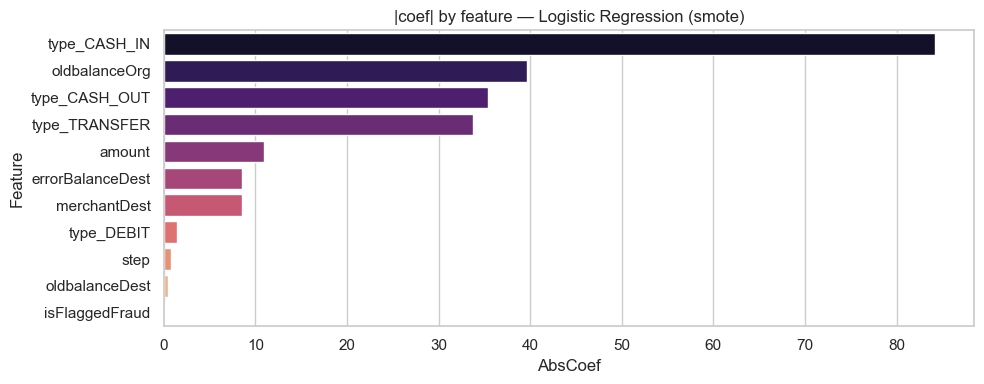


==================== sklearn | Random Forest | strategy=smote ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,62.0,59848.0,75.0,15.0,0.998500,0.452555,0.805195,0.579439,0.998748,0.998791,0.800306
1,2,62.0,59853.0,70.0,15.0,0.998583,0.469697,0.805195,0.593301,0.998832,0.984809,0.792456
2,3,61.0,59864.0,59.0,16.0,0.998750,0.508333,0.792208,0.619289,0.999015,0.992096,0.796003
3,4,71.0,59853.0,69.0,7.0,0.998733,0.507143,0.910256,0.651376,0.998849,0.992299,0.880279
4,5,67.0,59847.0,75.0,11.0,0.998567,0.471831,0.858974,0.609091,0.998748,0.998602,0.835513
5,Mean,64.6,59853.0,69.6,12.8,0.998627,0.481912,0.834366,0.610499,0.998839,0.993319,0.820911


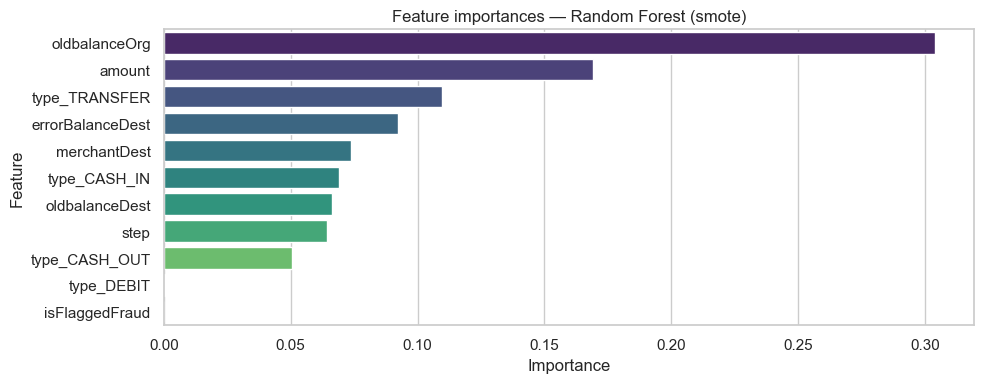


==================== sklearn | SVM | strategy=smote ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,67.0,56195.0,3728.0,10.0,0.937700,0.017655,0.870130,0.034607,0.937787,0.972421,0.345904
1,2,70.0,56132.0,3791.0,7.0,0.936700,0.018130,0.909091,0.035551,0.936735,0.976716,0.240095
2,3,73.0,56189.0,3734.0,4.0,0.937700,0.019175,0.948052,0.037590,0.937687,0.981780,0.257886
3,4,76.0,56158.0,3764.0,2.0,0.937233,0.019792,0.974359,0.038795,0.937185,0.988207,0.259213
4,5,68.0,56242.0,3680.0,10.0,0.938500,0.018143,0.871795,0.035546,0.938587,0.971004,0.324187
5,Mean,70.8,56183.2,3739.4,6.6,0.937567,0.018579,0.914685,0.036418,0.937596,0.978026,0.285457



==================== sklearn | Logistic Regression | strategy=undersample ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,65.0,47252.0,12671.0,12.0,0.788617,0.005104,0.844156,0.010146,0.788545,0.929018,0.267008
1,2,64.0,49677.0,10246.0,13.0,0.829017,0.006208,0.831169,0.012323,0.829014,0.924480,0.269911
2,3,72.0,49500.0,10423.0,5.0,0.826200,0.006860,0.935065,0.013621,0.826060,0.946679,0.146193
3,4,74.0,48551.0,11371.0,4.0,0.810417,0.006466,0.948718,0.012844,0.810237,0.956182,0.102656
4,5,67.0,46958.0,12964.0,11.0,0.783750,0.005142,0.858974,0.010222,0.783652,0.935413,0.321434
5,Mean,68.4,48387.6,11535.0,9.0,0.807600,0.005956,0.883616,0.011831,0.807502,0.938354,0.221441


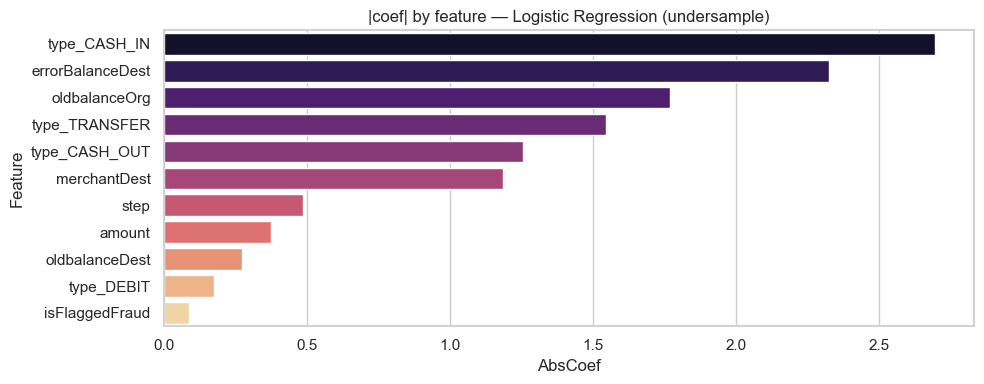


==================== sklearn | Random Forest | strategy=undersample ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,75.0,57139.0,2784.0,2.0,0.953567,0.026233,0.974026,0.051090,0.953540,0.995391,0.707581
1,2,73.0,57172.0,2751.0,4.0,0.954083,0.025850,0.948052,0.050327,0.954091,0.993227,0.545976
2,3,74.0,57408.0,2515.0,3.0,0.958033,0.028582,0.961039,0.055514,0.958029,0.993400,0.684528
3,4,78.0,57150.0,2772.0,0.0,0.953800,0.027368,1.000000,0.053279,0.953740,0.996905,0.681558
4,5,75.0,57063.0,2859.0,3.0,0.952300,0.025562,0.961538,0.049801,0.952288,0.995565,0.692376
5,Mean,75.0,57186.4,2736.2,2.4,0.954357,0.026719,0.968931,0.052002,0.954338,0.994898,0.662403


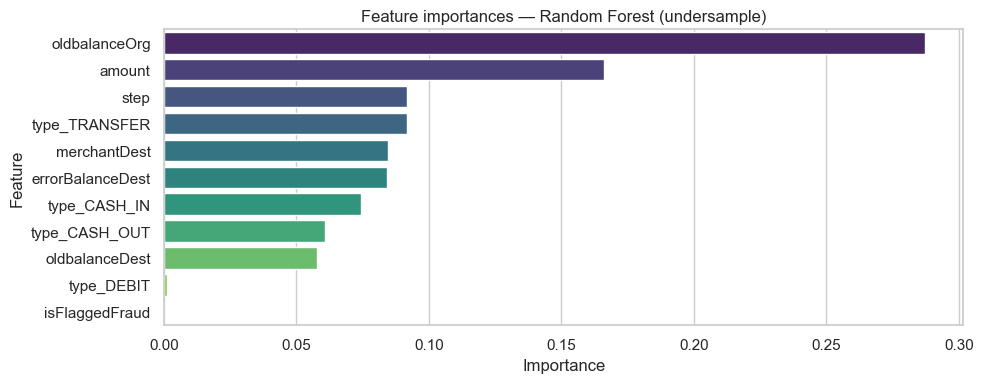


==================== sklearn | SVM | strategy=undersample ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,65.0,51032.0,8891.0,12.0,0.851617,0.007258,0.844156,0.014392,0.851626,0.943255,0.207147
1,2,66.0,52773.0,7150.0,11.0,0.880650,0.009146,0.857143,0.018100,0.880680,0.947539,0.281007
2,3,72.0,53247.0,6676.0,5.0,0.888650,0.010670,0.935065,0.021099,0.888590,0.965328,0.390710
3,4,75.0,53267.0,6655.0,3.0,0.889033,0.011144,0.961538,0.022033,0.888939,0.973403,0.052261
4,5,68.0,51512.0,8410.0,10.0,0.859667,0.008021,0.871795,0.015895,0.859651,0.951534,0.306621
5,Mean,69.2,52366.2,7556.4,8.2,0.873923,0.009248,0.893939,0.018304,0.873897,0.956212,0.247549


In [14]:
def make_sklearn_models(strategy: str):
    """LR, RF, SVM — class_weight only when strategy is class_weight (not with SMOTE/undersample)."""
    cw = "balanced" if strategy == "class_weight" else None
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight=cw,
            random_state=RANDOM_STATE,
            solver="lbfgs",
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            class_weight=cw,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "SVM": LinearSVC(
            class_weight=cw,
            random_state=RANDOM_STATE,
            max_iter=5000,
        ),
    }


for strategy in STRATEGIES:
    train_models_and_print_results(
        X, y, make_sklearn_models(strategy), strategy, "sklearn"
    )

## 6. Gradient Boosting (LightGBM, XGBoost)


scale_pos_weight (neg/pos): 774.1937984496124

==================== boosting | LightGBM | strategy=none ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,32.0,59811.0,112.0,45.0,0.997383,0.222222,0.415584,0.289593,0.998131,0.795273,0.194956
1,2,56.0,59908.0,15.0,21.0,0.999400,0.788732,0.727273,0.756757,0.999750,0.985465,0.740398
2,3,48.0,59916.0,7.0,29.0,0.999400,0.872727,0.623377,0.727273,0.999883,0.981767,0.764583
3,4,46.0,59848.0,74.0,32.0,0.998233,0.383333,0.589744,0.464646,0.998765,0.804851,0.362050
4,5,41.0,59837.0,85.0,37.0,0.997967,0.325397,0.525641,0.401961,0.998581,0.817551,0.330390
5,Mean,44.6,59864.0,58.6,32.8,0.998477,0.518482,0.576324,0.528046,0.999022,0.876981,0.478476


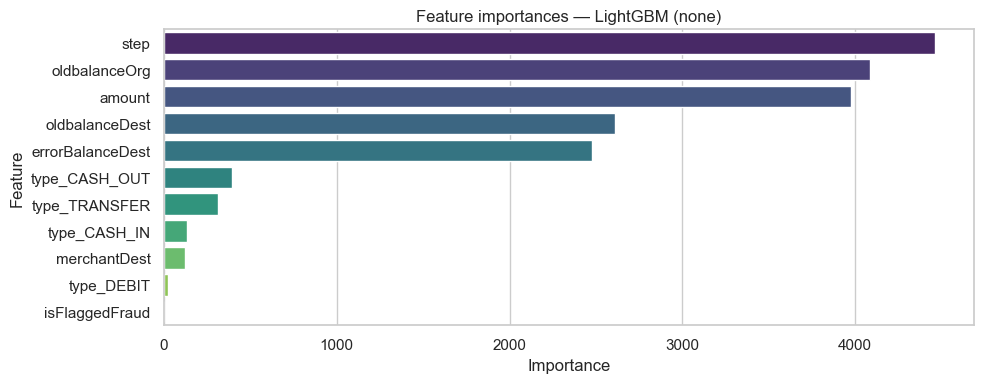


==================== boosting | XGBoost | strategy=none ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,54.0,59922.0,1.0,23.0,0.999600,0.981818,0.701299,0.818182,0.999983,0.998937,0.840567
1,2,55.0,59923.0,0.0,22.0,0.999633,1.000000,0.714286,0.833333,1.000000,0.998123,0.879947
2,3,51.0,59920.0,3.0,26.0,0.999517,0.944444,0.662338,0.778626,0.999950,0.998011,0.823766
3,4,64.0,59920.0,2.0,14.0,0.999733,0.969697,0.820513,0.888889,0.999967,0.999288,0.912715
4,5,58.0,59920.0,2.0,20.0,0.999633,0.966667,0.743590,0.840580,0.999967,0.997203,0.850682
5,Mean,56.4,59921.0,1.6,21.0,0.999623,0.972525,0.728405,0.831922,0.999973,0.998312,0.861536


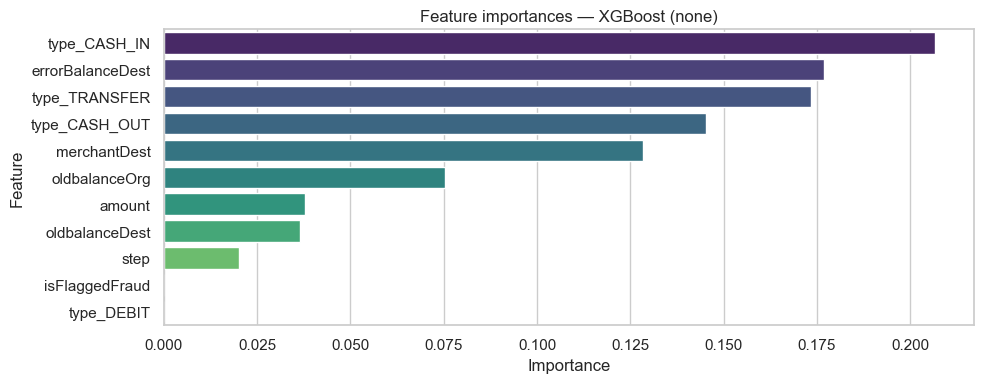


==================== boosting | LightGBM | strategy=class_weight ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,50.0,46154.0,13769.0,27.0,0.770067,0.003618,0.649351,0.007196,0.770222,0.709787,0.002801
1,2,48.0,55764.0,4159.0,29.0,0.930200,0.011410,0.623377,0.022409,0.930594,0.776957,0.007596
2,3,24.0,58029.0,1894.0,53.0,0.967550,0.012513,0.311688,0.024060,0.968393,0.638076,0.004783
3,4,72.0,55593.0,4329.0,6.0,0.927750,0.016360,0.923077,0.032150,0.927756,0.925411,0.015205
4,5,61.0,57058.0,2864.0,17.0,0.951983,0.020855,0.782051,0.040626,0.952205,0.867108,0.016593
5,Mean,51.0,54519.6,5403.0,26.4,0.909510,0.012951,0.657909,0.025288,0.909834,0.783468,0.009396


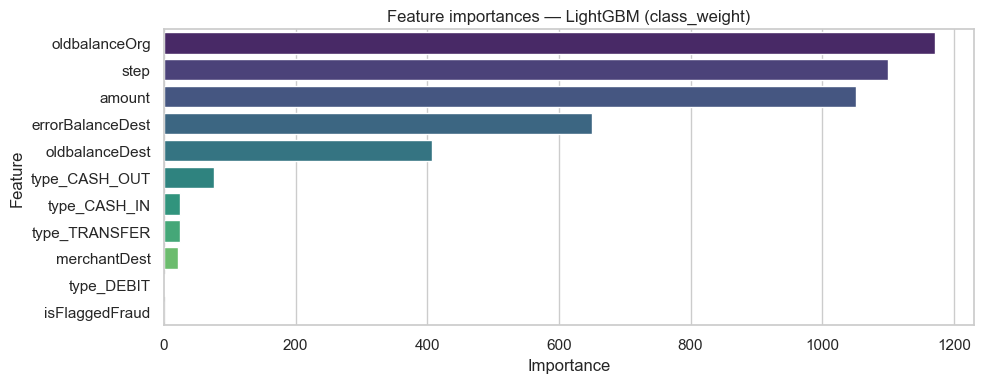


==================== boosting | XGBoost | strategy=class_weight ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,64.0,59876.0,47.0,13.0,0.999000,0.576577,0.831169,0.680851,0.999216,0.998978,0.851989
1,2,68.0,59870.0,53.0,9.0,0.998967,0.561983,0.883117,0.686869,0.999116,0.998589,0.885580
2,3,62.0,59868.0,55.0,15.0,0.998833,0.529915,0.805195,0.639175,0.999082,0.997223,0.816847
3,4,70.0,59863.0,59.0,8.0,0.998883,0.542636,0.897436,0.676329,0.999015,0.999304,0.908406
4,5,66.0,59863.0,59.0,12.0,0.998817,0.528000,0.846154,0.650246,0.999015,0.997542,0.854033
5,Mean,66.0,59868.0,54.6,11.4,0.998900,0.547822,0.852614,0.666694,0.999089,0.998327,0.863371


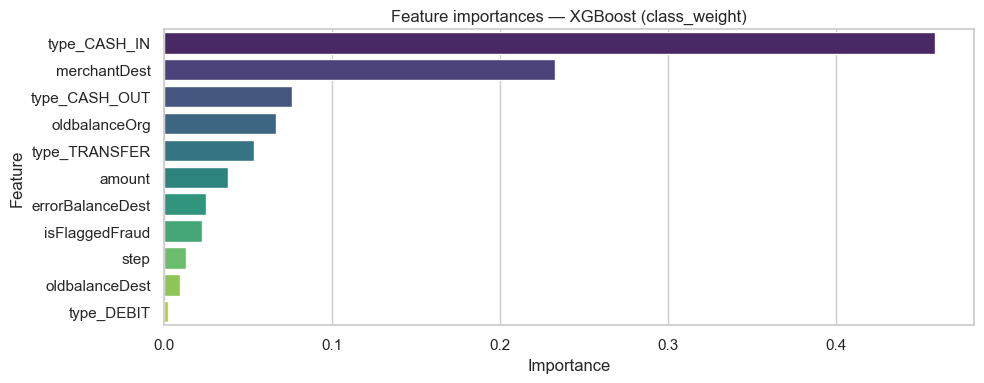


==================== boosting | LightGBM | strategy=smote ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,67.0,59802.0,121.0,10.0,0.997817,0.356383,0.870130,0.505660,0.997981,0.997939,0.847130
1,2,67.0,59823.0,100.0,10.0,0.998167,0.401198,0.870130,0.549180,0.998331,0.997964,0.834207
2,3,68.0,59804.0,119.0,9.0,0.997867,0.363636,0.883117,0.515152,0.998014,0.988203,0.814564
3,4,71.0,59814.0,108.0,7.0,0.998083,0.396648,0.910256,0.552529,0.998198,0.998803,0.901573
4,5,69.0,59786.0,136.0,9.0,0.997583,0.336585,0.884615,0.487633,0.997730,0.998713,0.875252
5,Mean,68.4,59805.8,116.8,9.0,0.997903,0.370890,0.883650,0.522031,0.998051,0.996324,0.854545


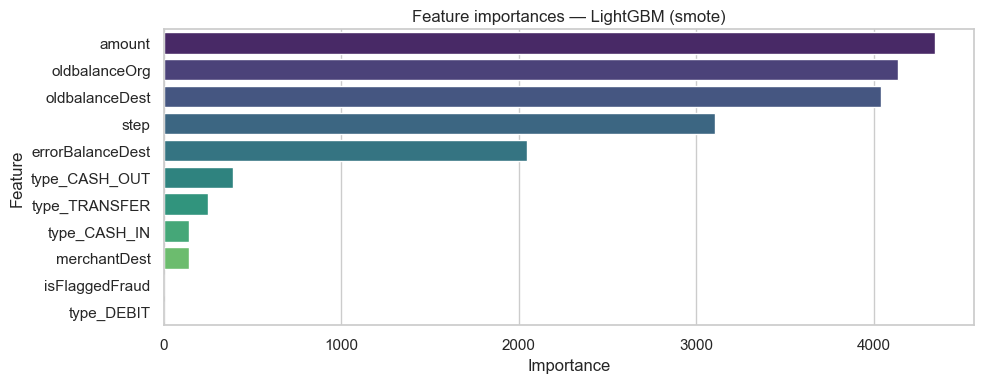


==================== boosting | XGBoost | strategy=smote ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,73.0,59606.0,317.0,4.0,0.994650,0.187179,0.948052,0.312634,0.994710,0.998297,0.856614
1,2,71.0,59652.0,271.0,6.0,0.995383,0.207602,0.922078,0.338902,0.995478,0.997462,0.846892
2,3,74.0,59653.0,270.0,3.0,0.995450,0.215116,0.961039,0.351544,0.995494,0.996243,0.846789
3,4,74.0,59566.0,356.0,4.0,0.994000,0.172093,0.948718,0.291339,0.994059,0.998868,0.913664
4,5,71.0,59634.0,288.0,7.0,0.995083,0.197772,0.910256,0.324943,0.995194,0.997981,0.861245
5,Mean,72.6,59622.2,300.4,4.8,0.994913,0.195953,0.938029,0.323872,0.994987,0.997770,0.865041


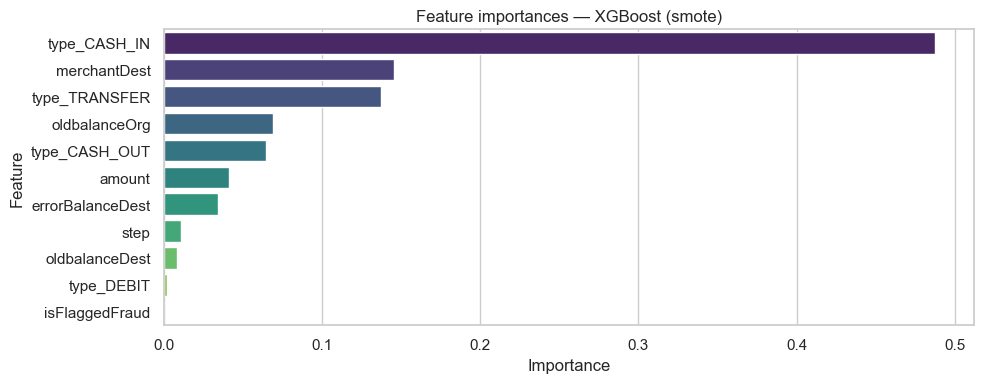


==================== boosting | LightGBM | strategy=undersample ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,76.0,57418.0,2505.0,1.0,0.958233,0.029446,0.987013,0.057186,0.958196,0.996755,0.733729
1,2,76.0,57633.0,2290.0,1.0,0.961817,0.032122,0.987013,0.062219,0.961784,0.995609,0.651907
2,3,75.0,57507.0,2416.0,2.0,0.959700,0.030108,0.974026,0.058411,0.959682,0.992209,0.684495
3,4,77.0,56724.0,3198.0,1.0,0.946683,0.023511,0.987179,0.045929,0.946631,0.996276,0.673942
4,5,76.0,57035.0,2887.0,2.0,0.951850,0.025650,0.974359,0.049984,0.951821,0.994965,0.558254
5,Mean,76.0,57263.4,2659.2,1.4,0.955657,0.028167,0.981918,0.054746,0.955623,0.995163,0.660466


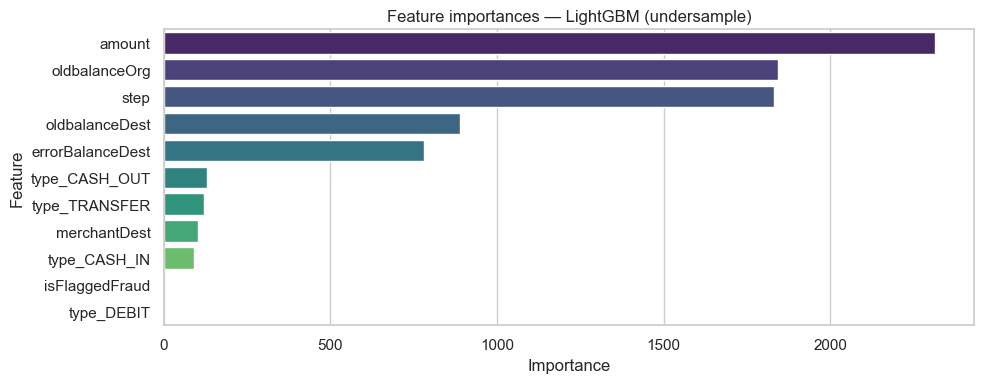


==================== boosting | XGBoost | strategy=undersample ====================


,Fold,TP,TN,FP,FN,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC,PR_AUC
0,1,73.0,57274.0,2649.0,4.0,0.955783,0.026819,0.948052,0.052161,0.955793,0.995185,0.704801
1,2,76.0,57071.0,2852.0,1.0,0.952450,0.025956,0.987013,0.050582,0.952406,0.993992,0.533442
2,3,74.0,57384.0,2539.0,3.0,0.957633,0.028320,0.961039,0.055019,0.957629,0.993978,0.646980
3,4,76.0,56783.0,3139.0,2.0,0.947650,0.023639,0.974359,0.046159,0.947615,0.995901,0.712739
4,5,75.0,57154.0,2768.0,3.0,0.953817,0.026381,0.961538,0.051352,0.953807,0.994455,0.585046
5,Mean,74.8,57133.2,2789.4,2.6,0.953467,0.026223,0.966400,0.051055,0.953450,0.994702,0.636602


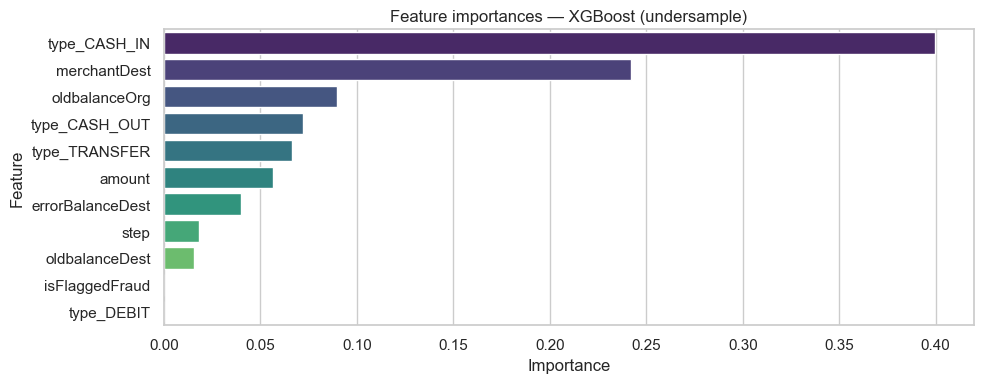

In [15]:
pos = int((y == 1).sum())
neg = int((y == 0).sum())
scale_pos_weight = neg / max(pos, 1)
print("scale_pos_weight (neg/pos):", scale_pos_weight)


def make_boosting_models(strategy: str):
    # For boosting, native imbalance handling is scale_pos_weight.
    # Use it for class_weight strategy; keep baseline=1 for other strategies.
    spw = scale_pos_weight if strategy == "class_weight" else 1.0
    return {
        "LightGBM": LGBMClassifier(
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=63,
            n_jobs=-1,
            verbose=-1,
        ),
        "XGBoost": XGBClassifier(
            scale_pos_weight=spw,
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="logloss",
        ),
    }


for strategy in STRATEGIES:
    train_models_and_print_results(X, y, make_boosting_models(strategy), strategy, "boosting")


## 7. Сравнителен анализ и заключения


,Family,Model,Strategy,Mean_Recall,Mean_Precision,Mean_F1,Mean_PR_AUC,Mean_ROC_AUC
17,boosting,XGBoost,smote,0.938029,0.195953,0.323872,0.865041,0.997770
15,boosting,XGBoost,class_weight,0.852614,0.547822,0.666694,0.863371,0.998327
13,boosting,XGBoost,none,0.728405,0.972525,0.831922,0.861536,0.998312
16,boosting,LightGBM,smote,0.883650,0.370890,0.522031,0.854545,0.996324
7,sklearn,Random Forest,smote,0.834366,0.481912,0.610499,0.820911,0.993319
4,sklearn,Random Forest,class_weight,0.692208,0.974788,0.808261,0.816184,0.965124
1,sklearn,Random Forest,none,0.699933,0.972013,0.812215,0.808043,0.959335
10,sklearn,Random Forest,undersample,0.968931,0.026719,0.052002,0.662403,0.994898
18,boosting,LightGBM,undersample,0.981918,0.028167,0.054746,0.660466,0.995163
19,boosting,XGBoost,undersample,0.966400,0.026223,0.051055,0.636602,0.994702


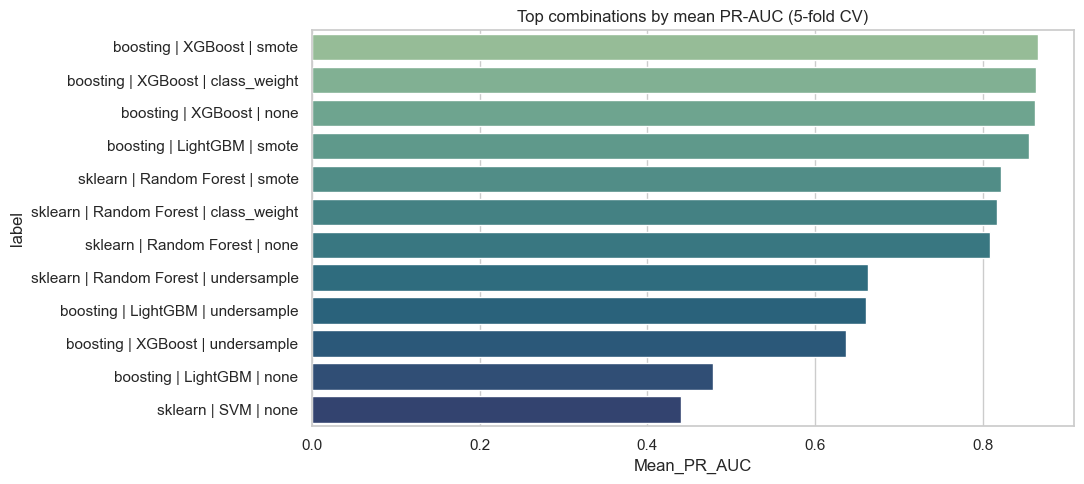

In [16]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["Mean_PR_AUC", "Mean_Recall"], ascending=False
)
display(summary_df.round(6))

plt.figure(figsize=(11, 5))
plot_df = summary_df.copy()
plot_df["label"] = plot_df["Family"] + " | " + plot_df["Model"] + " | " + plot_df["Strategy"]
topn = plot_df.head(12)
sns.barplot(data=topn, x="Mean_PR_AUC", y="label", palette="crest")
plt.title("Top combinations by mean PR-AUC (5-fold CV)")
plt.tight_layout()
plt.show()


## 8. Експорт на резултати за React дашборда

Следващата клетка записва `summary_df` в `dashboard/public/data/ml_results.json` за визуализация в SPA (статичен JSON).


In [17]:
import json
from datetime import datetime, timezone
from pathlib import Path

out_dir = Path("dashboard/public/data")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "ml_results.json"

payload = {
    "meta": {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "source": "scams-detection.ipynb",
    },
    "rows": summary_df.to_dict(orient="records"),
}
out_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print("Wrote", out_path.resolve())


Wrote /Users/todor.stamatov/scams-detections/dashboard/public/data/ml_results.json


### Експорт на фигури и Word документ за дипломната работа

След пълно изпълнение на notebook-а (или при наличие на `ml_results.json`) пуснете:

```bash
python scripts/export_thesis_figures.py
python scripts/generate_thesis_docx.py
```

Изход: `docs/thesis_figures/*.png` и `docs/Методи_за_детекция_на_финансови_измами.docx`